7 MACHINE LEARNING MODELS - PNEUMONIA DETECTION COMPARISON

📂 Loading dataset...
✅ Loaded: 4102 rows × 203 columns

📊 Class Distribution:
   Normal:     1109 (27.0%)
   Pneumonia:  2993 (73.0%)

DATA PREPARATION
✅ Training set: 3281 samples
✅ Test set: 821 samples
✅ Features scaled

TRAINING ALL MODELS

⏳ Training: Logistic Regression
   ✅ Training completed in 0.23 seconds
   📊 Accuracy:  0.9720 | Precision: 0.9848 | Recall: 0.9766 | F1: 0.9807 | AUC: 0.9928
   🏥 TN: 213 | FP: 9 | FN: 14 | TP: 585
   🏥 Sensitivity: 0.9766 | Specificity: 0.9595

⏳ Training: Random Forest
   ✅ Training completed in 4.69 seconds
   📊 Accuracy:  0.8965 | Precision: 0.8791 | Recall: 0.9950 | F1: 0.9334 | AUC: 0.9878
   🏥 TN: 140 | FP: 82 | FN: 3 | TP: 596
   🏥 Sensitivity: 0.9950 | Specificity: 0.6306

⏳ Training: Gradient Boosting
   ✅ Training completed in 118.31 seconds
   📊 Accuracy:  0.9598 | Precision: 0.9624 | Recall: 0.9833 | F1: 0.9727 | AUC: 0.9895
   🏥 TN: 199 | FP: 23 | FN: 10 | TP: 589
   🏥 Se

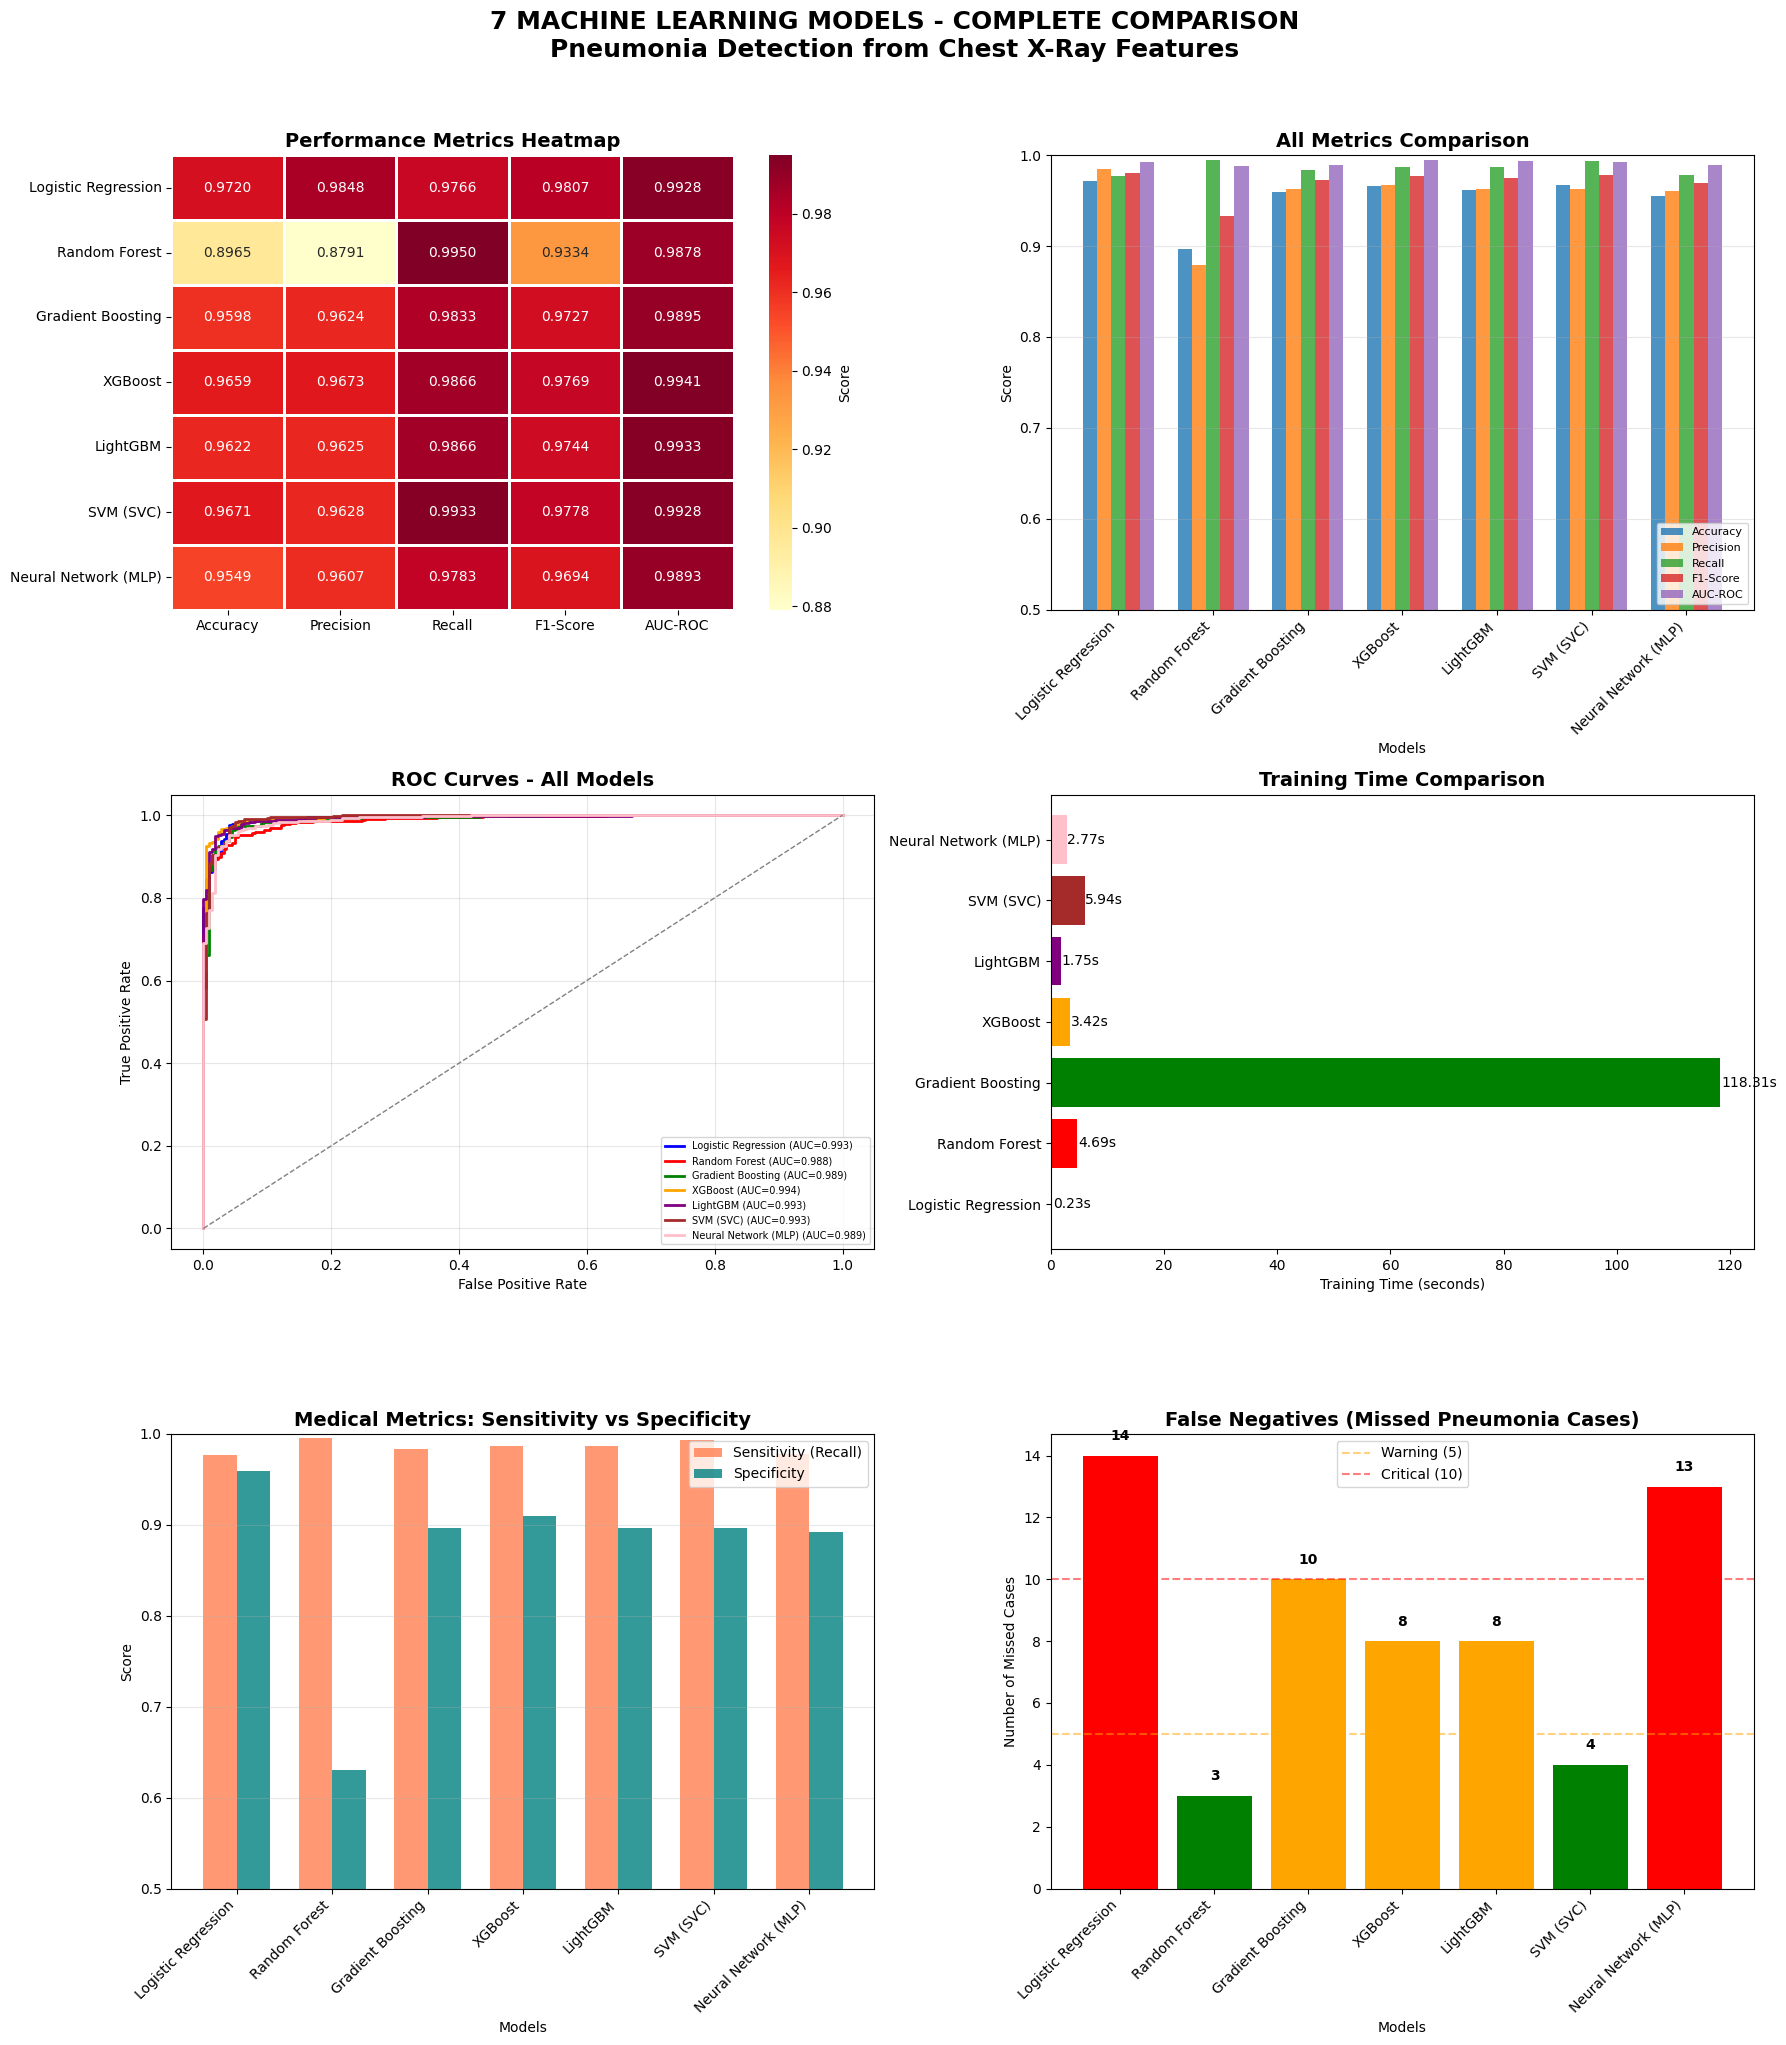

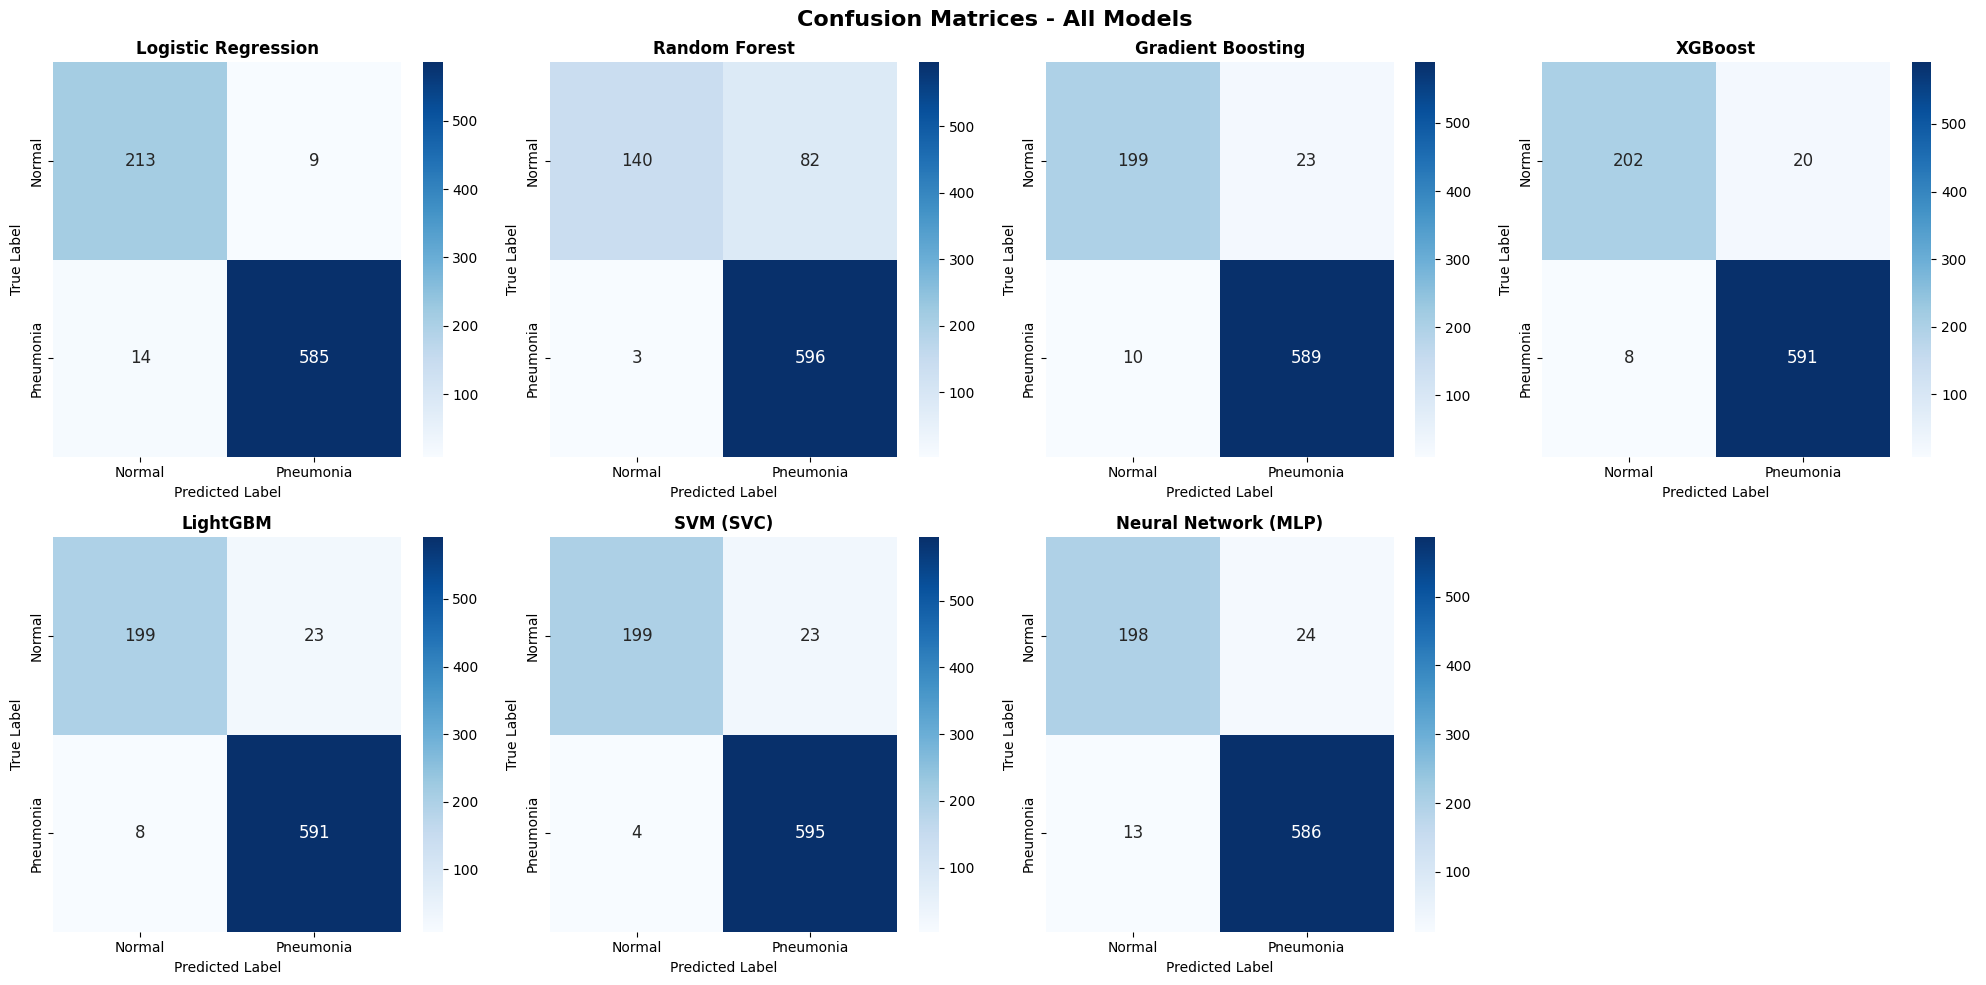


📝 MODEL SUMMARY

Model Characteristics:

1.  Logistic Regression     - Linear, fast, interpretable
2.  Random Forest           - Ensemble, robust, handles non-linearity
3.  Gradient Boosting       - Sequential ensemble, high accuracy
4.  XGBoost                 - Optimized gradient boosting, very fast
5.  LightGBM                - Lightweight gradient boosting, memory efficient
6.  SVM (SVC)               - Kernel-based, good for complex boundaries
7.  Neural Network (MLP)    - Deep learning, learns complex patterns

🏆 FINAL RECOMMENDATION

📊 Based on all metrics:

   Best Overall Model:       Logistic Regression
   Best for Medical Use:     Random Forest (Highest Recall = Fewest missed cases)

💡 MEDICAL APPLICATION INSIGHT:
   For pneumonia screening, RECALL (Sensitivity) is CRITICAL.
   Missing pneumonia can be life-threatening.
   
   Top 3 Models by Recall:
   1. Random Forest (Recall: 0.9950)
   2. SVM (SVC) (Recall: 0.9933)
   3. XGBoost (Recall: 0.9866)

⚡ Fastest Training:
   

In [2]:
# ============================================
# 7 MACHINE LEARNING MODELS COMPARISON
# PNEUMONIA DETECTION - ALL IN ONE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("7 MACHINE LEARNING MODELS - PNEUMONIA DETECTION COMPARISON")
print("="*80)

# ============================================
# 1. LOAD DATASET
# ============================================

csv_path = '/kaggle/input/datasets/mtishakil/chest-x-ray-feature-extracted-dataset-for-ml/Chest X-Ray Feature Extracted Dataset for ML.csv'

print(f"\n📂 Loading dataset...")
df = pd.read_csv(csv_path)
print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\n📊 Class Distribution:")
print(f"   Normal:     {len(df[df['Label']==0])} ({len(df[df['Label']==0])/len(df)*100:.1f}%)")
print(f"   Pneumonia:  {len(df[df['Label']==1])} ({len(df[df['Label']==1])/len(df)*100:.1f}%)")

# ============================================
# 2. PREPARE DATA
# ============================================

print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

X = df.drop(['Image_Name', 'Label', 'Class'], axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")
print(f"✅ Features scaled")

# ============================================
# 3. DEFINE ALL MODELS
# ============================================

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, penalty='l2', solver='lbfgs', max_iter=1000,
        class_weight='balanced', random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        min_samples_split=5, min_samples_leaf=2, random_state=42
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbose=-1
    ),
    
    'SVM (SVC)': SVC(
        kernel='rbf', C=10, gamma='scale', class_weight='balanced',
        probability=True, random_state=42
    ),
    
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(100, 50, 25), activation='relu',
        solver='adam', alpha=0.001, batch_size=32,
        learning_rate='adaptive', max_iter=500, random_state=42
    )
}

# Which models need scaling
needs_scaling = ['Logistic Regression', 'SVM (SVC)', 'Neural Network (MLP)']

# ============================================
# 4. TRAIN AND EVALUATE ALL MODELS
# ============================================

print("\n" + "="*80)
print("TRAINING ALL MODELS")
print("="*80)

results = {}
training_times = {}
all_predictions = {}
all_probabilities = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"⏳ Training: {name}")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    # Use scaled or unscaled data
    if name in needs_scaling:
        model.fit(X_train_scaled, y_train)
        if hasattr(model, 'predict_proba'):
            y_pred = model.predict(X_test_scaled)
            y_prob = model.predict_proba(X_test_scaled)
        else:
            y_pred = model.predict(X_test_scaled)
            y_prob = None
    else:
        model.fit(X_train, y_train)
        if hasattr(model, 'predict_proba'):
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)
        else:
            y_pred = model.predict(X_test)
            y_prob = None
    
    training_time = time.time() - start_time
    training_times[name] = training_time
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob[:, 1]) if y_prob is not None else 0
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'Predictions': y_pred,
        'Probabilities': y_prob
    }
    
    all_predictions[name] = y_pred
    all_probabilities[name] = y_prob
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"   ✅ Training completed in {training_time:.2f} seconds")
    print(f"   📊 Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print(f"   🏥 TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")
    print(f"   🏥 Sensitivity: {tp/(tp+fn):.4f} | Specificity: {tn/(tn+fp):.4f}")

# ============================================
# 5. COMPARISON TABLE
# ============================================

print("\n" + "="*80)
print("📊 MODEL COMPARISON TABLE")
print("="*80)

comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'AUC-ROC': metrics['AUC-ROC'],
        'Time (s)': training_times[name]
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)
print(f"\n{comparison_df.to_string(index=False)}")

# Find best models
best_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
best_recall = comparison_df.loc[comparison_df['Recall'].idxmax()]
best_precision = comparison_df.loc[comparison_df['Precision'].idxmax()]
best_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
best_auc = comparison_df.loc[comparison_df['AUC-ROC'].idxmax()]

print(f"\n🏆 BEST MODELS:")
print(f"   Best Accuracy:   {best_accuracy['Model']} ({best_accuracy['Accuracy']:.4f})")
print(f"   Best Precision:  {best_precision['Model']} ({best_precision['Precision']:.4f})")
print(f"   Best Recall:     {best_recall['Model']} ({best_recall['Recall']:.4f})")
print(f"   Best F1-Score:   {best_f1['Model']} ({best_f1['F1-Score']:.4f})")
print(f"   Best AUC-ROC:    {best_auc['Model']} ({best_auc['AUC-ROC']:.4f})")

# ============================================
# 6. DETAILED CLASSIFICATION REPORTS
# ============================================

print("\n" + "="*80)
print("📋 CLASSIFICATION REPORTS")
print("="*80)

for name in models.keys():
    print(f"\n{'='*40}")
    print(f"📋 {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, all_predictions[name], 
                                target_names=['Normal', 'Pneumonia']))

# ============================================
# 7. MEDICAL METRICS COMPARISON
# ============================================

print("\n" + "="*80)
print("🏥 MEDICAL METRICS COMPARISON")
print("="*80)

medical_data = []
for name in models.keys():
    cm = confusion_matrix(y_test, all_predictions[name])
    tn, fp, fn, tp = cm.ravel()
    medical_data.append({
        'Model': name,
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Sensitivity': tp/(tp+fn),
        'Specificity': tn/(tn+fp),
        'PPV': tp/(tp+fp),
        'NPV': tn/(tn+fn)
    })

medical_df = pd.DataFrame(medical_data)
medical_df = medical_df.round(4)
print(f"\n{medical_df.to_string(index=False)}")

# Highlight missed pneumonia cases
print(f"\n⚠️  MISSED PNEUMONIA CASES (FALSE NEGATIVES):")
for name in models.keys():
    cm = confusion_matrix(y_test, all_predictions[name])
    fn = cm.ravel()[2]
    status = '❌ CRITICAL!' if fn > 10 else ('⚠️  Warning' if fn > 5 else '✅ Good')
    print(f"   {name:<25} : {fn:3d} missed  {status}")

# ============================================
# 8. VISUALIZATIONS
# ============================================

print("\n" + "="*80)
print("📈 GENERATING VISUALIZATIONS")
print("="*80)

# 8.1 Performance Heatmap
fig, axes = plt.subplots(3, 2, figsize=(18, 20))

# Heatmap of all metrics
metrics_matrix = comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
sns.heatmap(metrics_matrix, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0, 0], 
            cbar_kws={'label': 'Score'}, linewidths=1, linecolor='white')
axes[0, 0].set_title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('')

# Bar Chart - All Metrics
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(comparison_df))
width = 0.15

for i, metric in enumerate(metrics_cols):
    offset = (i - len(metrics_cols)/2 + 0.5) * width
    axes[0, 1].bar(x + offset, comparison_df[metric], width, label=metric, alpha=0.8)

axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 1].legend(loc='lower right', fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_ylim([0.5, 1.0])

# ROC Curves
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']
for i, name in enumerate(models.keys()):
    if all_probabilities[name] is not None:
        fpr, tpr, _ = roc_curve(y_test, all_probabilities[name][:, 1])
        auc = results[name]['AUC-ROC']
        axes[1, 0].plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC={auc:.3f})')

axes[1, 0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='lower right', fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

# Training Time Comparison
axes[1, 1].barh(comparison_df['Model'], comparison_df['Time (s)'], color=colors)
axes[1, 1].set_xlabel('Training Time (seconds)')
axes[1, 1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(comparison_df['Time (s)']):
    axes[1, 1].text(v + 0.1, i, f'{v:.2f}s', va='center')

# Medical Metrics: Sensitivity vs Specificity
sensitivity_values = medical_df['Sensitivity'].values
specificity_values = medical_df['Specificity'].values

x_med = np.arange(len(medical_df))
width_med = 0.35

axes[2, 0].bar(x_med - width_med/2, sensitivity_values, width_med, label='Sensitivity (Recall)', color='coral', alpha=0.8)
axes[2, 0].bar(x_med + width_med/2, specificity_values, width_med, label='Specificity', color='teal', alpha=0.8)
axes[2, 0].set_xlabel('Models')
axes[2, 0].set_ylabel('Score')
axes[2, 0].set_title('Medical Metrics: Sensitivity vs Specificity', fontsize=14, fontweight='bold')
axes[2, 0].set_xticks(x_med)
axes[2, 0].set_xticklabels(medical_df['Model'], rotation=45, ha='right')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3, axis='y')
axes[2, 0].set_ylim([0.5, 1.0])

# False Negatives (Missed Pneumonia)
fn_values = medical_df['False Negatives'].values
bars = axes[2, 1].bar(medical_df['Model'], fn_values, color=['green' if v <= 5 else 'orange' if v <= 10 else 'red' for v in fn_values])
axes[2, 1].set_xlabel('Models')
axes[2, 1].set_ylabel('Number of Missed Cases')
axes[2, 1].set_title('False Negatives (Missed Pneumonia Cases)', fontsize=14, fontweight='bold')
axes[2, 1].set_xticklabels(medical_df['Model'], rotation=45, ha='right')
for bar, v in zip(bars, fn_values):
    axes[2, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(v), ha='center', fontweight='bold')
axes[2, 1].axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='Warning (5)')
axes[2, 1].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Critical (10)')
axes[2, 1].legend()

plt.suptitle('7 MACHINE LEARNING MODELS - COMPLETE COMPARISON\nPneumonia Detection from Chest X-Ray Features', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 9. CONFUSION MATRICES GRID
# ============================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, all_predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'],
                annot_kws={'size': 12})
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

# Remove extra subplot if exists
if len(models) < 8:
    axes[-1].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 10. SUMMARY & RECOMMENDATION
# ============================================

print("\n" + "="*80)
print("📝 MODEL SUMMARY")
print("="*80)

print(f"""
Model Characteristics:

1.  Logistic Regression     - Linear, fast, interpretable
2.  Random Forest           - Ensemble, robust, handles non-linearity
3.  Gradient Boosting       - Sequential ensemble, high accuracy
4.  XGBoost                 - Optimized gradient boosting, very fast
5.  LightGBM                - Lightweight gradient boosting, memory efficient
6.  SVM (SVC)               - Kernel-based, good for complex boundaries
7.  Neural Network (MLP)    - Deep learning, learns complex patterns
""")

print("="*80)
print("🏆 FINAL RECOMMENDATION")
print("="*80)

print(f"""
📊 Based on all metrics:

   Best Overall Model:       {best_accuracy['Model']}
   Best for Medical Use:     {best_recall['Model']} (Highest Recall = Fewest missed cases)

💡 MEDICAL APPLICATION INSIGHT:
   For pneumonia screening, RECALL (Sensitivity) is CRITICAL.
   Missing pneumonia can be life-threatening.
   
   Top 3 Models by Recall:
   1. {comparison_df.sort_values('Recall', ascending=False).iloc[0]['Model']} (Recall: {comparison_df.sort_values('Recall', ascending=False).iloc[0]['Recall']:.4f})
   2. {comparison_df.sort_values('Recall', ascending=False).iloc[1]['Model']} (Recall: {comparison_df.sort_values('Recall', ascending=False).iloc[1]['Recall']:.4f})
   3. {comparison_df.sort_values('Recall', ascending=False).iloc[2]['Model']} (Recall: {comparison_df.sort_values('Recall', ascending=False).iloc[2]['Recall']:.4f})

⚡ Fastest Training:
   {comparison_df.sort_values('Time (s)').iloc[0]['Model']} ({comparison_df.sort_values('Time (s)').iloc[0]['Time (s)']:.2f}s)
""")

print("="*80)
print("✅ ALL 7 MODELS TRAINED AND COMPARED SUCCESSFULLY!")
print("="*80)